# VisA Data Download, Validation, and Manifest Creation

This notebook prepares the Visual Anomaly (VisA) dataset for DINOv2 anomaly
detection and patch-level localization.

It:

1. downloads the official VisA archive when needed;
2. extracts it safely;
3. validates all 12 object classes;
4. checks normal, anomaly, and mask files;
5. verifies that anomaly images have matching masks;
6. creates a portable CSV manifest;
7. displays representative normal, anomalous, and mask samples.

Model inference and DINOv2 embeddings belong in the next notebook.


## Dataset Facts

VisA contains 10,821 images across 12 object classes:

```text
candle, capsules, cashew, chewinggum, fryum,
macaroni1, macaroni2, pcb1, pcb2, pcb3, pcb4, pipe_fryum
```

The original layout stores normal and anomalous images under `Data/Images`.
Only anomalous images have masks under `Data/Masks/Anomaly`.


In [1]:
# Run only if the server environment is missing these packages:
%pip install "numpy<2.3" "pandas<3" pillow matplotlib



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import csv
import json
import shutil
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

VISA_URL = (
    "https://amazon-visual-anomaly.s3.us-west-2.amazonaws.com/"
    "VisA_20220922.tar"
)
EXPECTED_CLASSES = (
    "candle",
    "capsules",
    "cashew",
    "chewinggum",
    "fryum",
    "macaroni1",
    "macaroni2",
    "pcb1",
    "pcb2",
    "pcb3",
    "pcb4",
    "pipe_fryum",
)
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp"}

# Supports execution from repository root or notebooks/vision on the server.
DATA_ROOT = Path("../data") if Path.cwd().name == "vision" else Path("data")
ARCHIVE_PATH = DATA_ROOT / "VisA_20220922.tar"
EXTRACT_ROOT = DATA_ROOT / "_visa_extract"
VISA_DIR = DATA_ROOT / "VisA"
MANIFEST_DIR = (
    Path("artifacts/visa")
    if Path.cwd().name != "vision"
    else Path("artifacts/visa")
)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd().resolve())
print("Data root:", DATA_ROOT.resolve())
print("Expected VisA directory:", VISA_DIR.resolve())


Working directory: /workspace/notebooks/vision
Data root: /workspace/notebooks/data
Expected VisA directory: /workspace/notebooks/data/VisA


## 1. Safe, Idempotent Download and Extraction


In [7]:
def class_layout_exists(root: Path, class_name: str) -> bool:
    class_dir = root / class_name
    return (
        (class_dir / "Data" / "Images" / "Normal").is_dir()
        and (class_dir / "Data" / "Images" / "Anomaly").is_dir()
        and (class_dir / "Data" / "Masks" / "Anomaly").is_dir()
    )


def dataset_is_complete(root: Path) -> bool:
    return all(class_layout_exists(root, name) for name in EXPECTED_CLASSES)


def safe_extract_tar(archive_path: Path, destination: Path) -> None:
    destination.mkdir(parents=True, exist_ok=True)
    destination_resolved = destination.resolve()

    with tarfile.open(archive_path) as archive:
        for member in archive.getmembers():
            target = (destination / member.name).resolve()
            if (
                destination_resolved not in target.parents
                and target != destination_resolved
            ):
                raise ValueError(f"Unsafe archive member: {member.name}")

        archive.extractall(destination, filter="data")



def find_visa_root(search_root: Path) -> Path:
    candidates = [search_root]
    candidates.extend(path for path in search_root.rglob("VisA") if path.is_dir())
    for candidate in candidates:
        if dataset_is_complete(candidate):
            return candidate
    raise FileNotFoundError("Could not find a complete VisA directory.")


In [8]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if dataset_is_complete(VISA_DIR):
    print("VisA is already complete. Download and extraction skipped.")
else:
    if not ARCHIVE_PATH.is_file():
        print("Downloading the official VisA archive...")

        def report_progress(block_count, block_size, total_size):
            downloaded = block_count * block_size
            if total_size > 0:
                percent = min(100, downloaded * 100 / total_size)
                print(
                    f"\rDownloaded {downloaded / 1024**3:.2f} GB "
                    f"({percent:.1f}%)",
                    end="",
                )

        urllib.request.urlretrieve(
            VISA_URL,
            ARCHIVE_PATH,
            reporthook=report_progress,
        )
        print("\nDownload complete:", ARCHIVE_PATH.resolve())
    else:
        print("Using existing archive:", ARCHIVE_PATH.resolve())

    if EXTRACT_ROOT.exists():
        shutil.rmtree(EXTRACT_ROOT)

    print("Extracting archive...")
    safe_extract_tar(ARCHIVE_PATH, EXTRACT_ROOT)
    extracted_visa = find_visa_root(EXTRACT_ROOT)

    if VISA_DIR.exists():
        shutil.rmtree(VISA_DIR)
    shutil.move(str(extracted_visa), str(VISA_DIR))
    print("Dataset normalized to:", VISA_DIR.resolve())

if not dataset_is_complete(VISA_DIR):
    raise RuntimeError("VisA preparation failed: required class folders are missing.")


VisA is already complete. Download and extraction skipped.


## 2. Inventory and Path Validation


In [9]:
def image_files(folder: Path):
    return sorted(
        path
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )


summary_rows = []

for class_name in EXPECTED_CLASSES:
    class_dir = VISA_DIR / class_name
    normal_images = image_files(class_dir / "Data" / "Images" / "Normal")
    anomaly_images = image_files(class_dir / "Data" / "Images" / "Anomaly")
    anomaly_masks = image_files(class_dir / "Data" / "Masks" / "Anomaly")

    summary_rows.append(
        {
            "class_name": class_name,
            "normal_images": len(normal_images),
            "anomaly_images": len(anomaly_images),
            "anomaly_masks": len(anomaly_masks),
            "has_annotation_csv": (class_dir / "image_anno.csv").is_file(),
        }
    )

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)
display(dataset_summary.sum(numeric_only=True).to_frame("total").T)

if (dataset_summary[["normal_images", "anomaly_images"]] == 0).any().any():
    raise ValueError("At least one VisA class has no normal or anomalous images.")

print("All 12 class directories contain normal and anomalous images.")


,class_name,normal_images,anomaly_images,anomaly_masks,has_annotation_csv
0,candle,1000,100,100,True
1,capsules,602,100,100,True
2,cashew,500,100,100,True
3,chewinggum,503,100,100,True
4,fryum,500,100,100,True
5,macaroni1,1000,100,100,True
6,macaroni2,1000,100,100,True
7,pcb1,1004,100,100,True
8,pcb2,1001,100,100,True
9,pcb3,1006,100,100,True


,normal_images,anomaly_images,anomaly_masks,has_annotation_csv
total,9621,1200,1200,12


All 12 class directories contain normal and anomalous images.


## 3. Build a Dataset Manifest

The class annotation CSV is the authoritative image-to-mask mapping. The
manifest stores paths relative to `VisA/` so it remains portable when moved
between this machine and the AMD server.


In [10]:
def normalize_label(value: str) -> str:
    value = str(value).strip().lower()
    if value in {"normal", "good", "0"}:
        return "normal"
    return "anomaly"


manifest_rows = []

for class_name in EXPECTED_CLASSES:
    class_dir = VISA_DIR / class_name
    annotation_path = class_dir / "image_anno.csv"

    if not annotation_path.is_file():
        raise FileNotFoundError(f"Missing annotation file: {annotation_path}")

    annotations = pd.read_csv(annotation_path)
    normalized_columns = {
        column.lower().strip(): column for column in annotations.columns
    }

    image_column = next(
        (
            normalized_columns[name]
            for name in ("image", "image_path", "image_name")
            if name in normalized_columns
        ),
        None,
    )
    mask_column = next(
        (
            normalized_columns[name]
            for name in ("mask", "mask_path", "mask_name")
            if name in normalized_columns
        ),
        None,
    )
    label_column = next(
        (
            normalized_columns[name]
            for name in ("label", "class", "anomaly")
            if name in normalized_columns
        ),
        None,
    )

    if image_column is None or label_column is None:
        raise ValueError(
            f"Unsupported annotation columns for {class_name}: "
            f"{list(annotations.columns)}"
        )

    for _, row in annotations.iterrows():
        label = normalize_label(row[label_column])
        raw_image_path = str(row[image_column]).strip()
        image_path = Path(raw_image_path)
        if not image_path.is_absolute():
            image_path = VISA_DIR / image_path
            if not image_path.is_file():
                image_path = class_dir / raw_image_path

        mask_path = None
        if label == "anomaly" and mask_column is not None:
            raw_mask = str(row[mask_column]).strip()
            if raw_mask and raw_mask.lower() != "nan":
                candidate = Path(raw_mask)
                if not candidate.is_absolute():
                    candidate = VISA_DIR / candidate
                    if not candidate.is_file():
                        candidate = class_dir / raw_mask
                mask_path = candidate

        manifest_rows.append(
            {
                "class_name": class_name,
                "label": label,
                "image_path": (
                    image_path.relative_to(VISA_DIR).as_posix()
                    if image_path.is_file()
                    else raw_image_path
                ),
                "mask_path": (
                    mask_path.relative_to(VISA_DIR).as_posix()
                    if mask_path is not None and mask_path.is_file()
                    else ""
                ),
                "image_exists": image_path.is_file(),
                "mask_exists": (
                    True if label == "normal"
                    else mask_path is not None and mask_path.is_file()
                ),
            }
        )

manifest = pd.DataFrame(manifest_rows)
display(manifest.head())
display(
    manifest.groupby(["class_name", "label"])
    .size()
    .unstack(fill_value=0)
)

invalid_images = manifest[~manifest["image_exists"]]
invalid_masks = manifest[
    (manifest["label"] == "anomaly") & (~manifest["mask_exists"])
]

print("Missing images:", len(invalid_images))
print("Missing anomaly masks:", len(invalid_masks))

if len(invalid_images) or len(invalid_masks):
    display(pd.concat([invalid_images.head(), invalid_masks.head()]))
    raise ValueError("Manifest contains missing image or mask paths.")


,class_name,label,image_path,mask_path,image_exists,mask_exists
0,candle,normal,candle/Data/Images/Normal/0000.JPG,,True,True
1,candle,normal,candle/Data/Images/Normal/0001.JPG,,True,True
2,candle,normal,candle/Data/Images/Normal/0002.JPG,,True,True
3,candle,normal,candle/Data/Images/Normal/0003.JPG,,True,True
4,candle,normal,candle/Data/Images/Normal/0004.JPG,,True,True


label,anomaly,normal
class_name,,
candle,100,1000
capsules,100,602
cashew,100,500
chewinggum,100,503
fryum,100,500
macaroni1,100,1000
macaroni2,100,1000
pcb1,100,1004
pcb2,100,1001


Missing images: 0
Missing anomaly masks: 0


## 4. Verify Image and Mask Readability


In [11]:
def inspect_image(path: Path):
    with Image.open(path) as image:
        image.verify()
    with Image.open(path) as image:
        return image.size, image.mode


readability_rows = []
sampled = (
    manifest.groupby(["class_name", "label"], group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

for _, row in sampled.iterrows():
    image_path = VISA_DIR / row["image_path"]
    size, mode = inspect_image(image_path)
    readability_rows.append(
        {
            "class_name": row["class_name"],
            "label": row["label"],
            "image_path": row["image_path"],
            "width": size[0],
            "height": size[1],
            "mode": mode,
        }
    )

    if row["label"] == "anomaly":
        mask_path = VISA_DIR / row["mask_path"]
        mask_size, _ = inspect_image(mask_path)
        if mask_size != size:
            raise ValueError(
                f"Image/mask size mismatch: {image_path} and {mask_path}"
            )

readability = pd.DataFrame(readability_rows)
display(readability)
print("Sampled images and masks are readable and dimensionally aligned.")


,class_name,label,image_path,width,height,mode
0,candle,normal,candle/Data/Images/Normal/0000.JPG,1284,1168,RGB
1,candle,normal,candle/Data/Images/Normal/0001.JPG,1284,1168,RGB
2,candle,anomaly,candle/Data/Images/Anomaly/000.JPG,1284,1168,RGB
3,candle,anomaly,candle/Data/Images/Anomaly/001.JPG,1284,1168,RGB
4,capsules,normal,capsules/Data/Images/Normal/000.JPG,1500,1000,RGB
5,capsules,normal,capsules/Data/Images/Normal/001.JPG,1500,1000,RGB
6,capsules,anomaly,capsules/Data/Images/Anomaly/000.JPG,1500,1000,RGB
7,capsules,anomaly,capsules/Data/Images/Anomaly/001.JPG,1500,1000,RGB
8,cashew,normal,cashew/Data/Images/Normal/000.JPG,1274,1176,RGB
9,cashew,normal,cashew/Data/Images/Normal/001.JPG,1274,1176,RGB


Sampled images and masks are readable and dimensionally aligned.


## 5. Visual Sanity Check


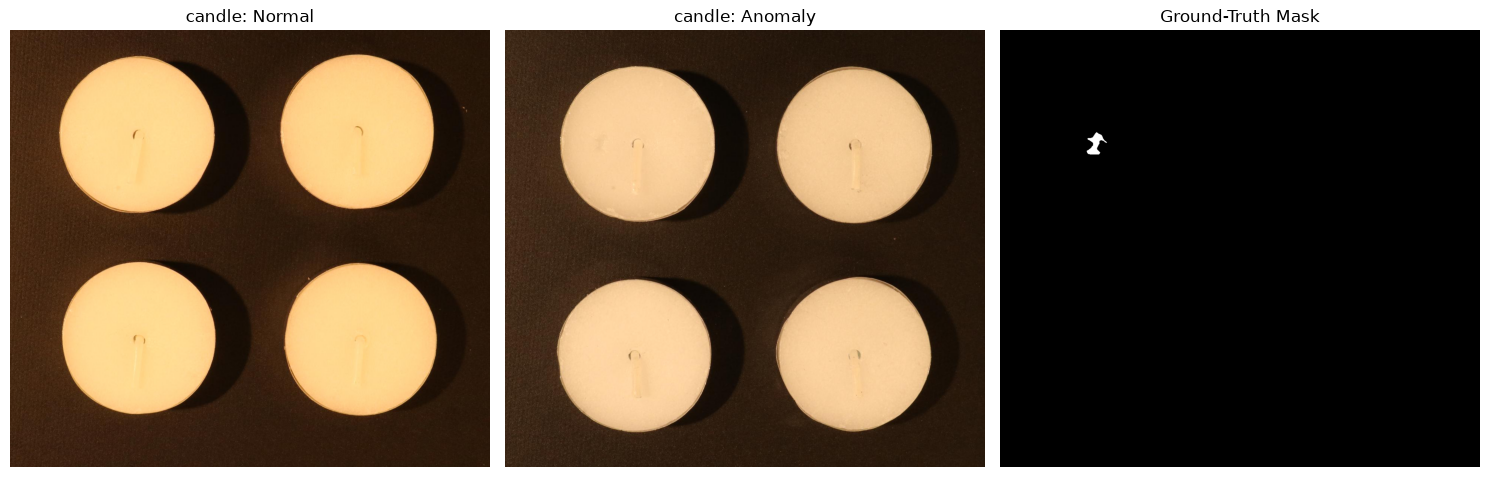

In [12]:
sample_class = "candle"
normal_row = manifest[
    (manifest["class_name"] == sample_class)
    & (manifest["label"] == "normal")
].iloc[0]
anomaly_row = manifest[
    (manifest["class_name"] == sample_class)
    & (manifest["label"] == "anomaly")
].iloc[0]

normal_image = Image.open(VISA_DIR / normal_row["image_path"]).convert("RGB")
anomaly_image = Image.open(VISA_DIR / anomaly_row["image_path"]).convert("RGB")
mask = Image.open(VISA_DIR / anomaly_row["mask_path"]).convert("L")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(normal_image)
axes[0].set_title(f"{sample_class}: Normal")
axes[1].imshow(anomaly_image)
axes[1].set_title(f"{sample_class}: Anomaly")
axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Ground-Truth Mask")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


## 6. Save Manifest and Dataset Report


In [13]:
manifest_path = MANIFEST_DIR / "visa_manifest.csv"
summary_path = MANIFEST_DIR / "visa_dataset_summary.csv"
report_path = MANIFEST_DIR / "visa_validation_report.json"

manifest[
    ["class_name", "label", "image_path", "mask_path"]
].to_csv(manifest_path, index=False)
dataset_summary.to_csv(summary_path, index=False)

report = {
    "dataset": "Visual Anomaly (VisA)",
    "dataset_root": str(VISA_DIR.resolve()),
    "class_count": len(EXPECTED_CLASSES),
    "classes": list(EXPECTED_CLASSES),
    "normal_images": int((manifest["label"] == "normal").sum()),
    "anomaly_images": int((manifest["label"] == "anomaly").sum()),
    "anomaly_masks": int(
        ((manifest["label"] == "anomaly") & manifest["mask_exists"]).sum()
    ),
    "missing_images": int((~manifest["image_exists"]).sum()),
    "missing_anomaly_masks": int(
        ((manifest["label"] == "anomaly") & (~manifest["mask_exists"])).sum()
    ),
}
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("Saved manifest:", manifest_path.resolve())
print("Saved summary:", summary_path.resolve())
print("Saved report:", report_path.resolve())
print(json.dumps(report, indent=2))


Saved manifest: /workspace/notebooks/vision/artifacts/visa/visa_manifest.csv
Saved summary: /workspace/notebooks/vision/artifacts/visa/visa_dataset_summary.csv
Saved report: /workspace/notebooks/vision/artifacts/visa/visa_validation_report.json
{
  "dataset": "Visual Anomaly (VisA)",
  "dataset_root": "/workspace/notebooks/data/VisA",
  "class_count": 12,
  "classes": [
    "candle",
    "capsules",
    "cashew",
    "chewinggum",
    "fryum",
    "macaroni1",
    "macaroni2",
    "pcb1",
    "pcb2",
    "pcb3",
    "pcb4",
    "pipe_fryum"
  ],
  "normal_images": 9621,
  "anomaly_images": 1200,
  "anomaly_masks": 1200,
  "missing_images": 0,
  "missing_anomaly_masks": 0
}
